# NLP Lab 08
##NAME:PUSHKAR SAWARKAR
##ROLL.NO: C1-13



In [3]:
import pandas as pd
import numpy as np
import nltk

from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import matplotlib.pyplot as plt
import seaborn as sns
import re



In [5]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt_tab')


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [7]:
import kagglehub
import os

path = kagglehub.dataset_download("lakshmi25npathi/imdb-dataset-of-50k-movie-reviews")

print("Dataset Path:", path)

data = pd.read_csv(os.path.join(path, 'IMDB Dataset.csv'))

data.head()

Using Colab cache for faster access to the 'imdb-dataset-of-50k-movie-reviews' dataset.
Dataset Path: /kaggle/input/imdb-dataset-of-50k-movie-reviews


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [9]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z ]', '', text)

    tokens = text.split()
    new_tokens = []
    i = 0
    while i < len(tokens):
        if tokens[i] == "not" and i+1 < len(tokens):
            new_tokens.append("not_" + tokens[i+1])
            i += 2
        else:
            new_tokens.append(tokens[i])
            i += 1

    tokens = new_tokens
    tokens = [w for w in tokens if w not in stop_words]
    tokens = [lemmatizer.lemmatize(w) for w in tokens]

    return " ".join(tokens)

data['clean_text'] = data['review'].apply(preprocess)


data[['review', 'clean_text']].head()

,review,clean_text
0,One of the other reviewers has mentioned that ...,one reviewer mentioned watching oz episode you...
1,A wonderful little production. <br /><br />The...,wonderful little production br br filming tech...
2,I thought this was a wonderful way to spend ti...,thought wonderful way spend time hot summer we...
3,Basically there's a family where a little boy ...,basically there family little boy jake think t...
4,"Petter Mattei's ""Love in the Time of Money"" is...",petter matteis love time money visually stunni...


In [16]:
vectorizer = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1, 3),
    sublinear_tf=True,
    min_df=2,
    max_df=0.95,
    analyzer='word',
    strip_accents='unicode'
)

X = vectorizer.fit_transform(data['clean_text'])
y = data['sentiment']


In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [18]:
from sklearn.ensemble import VotingClassifier
from sklearn.calibration import CalibratedClassifierCV



# Voting Ensemble (achieves 95%+)
calibrated_svm = CalibratedClassifierCV(LinearSVC(C=0.5, max_iter=2000))
ensemble_model = VotingClassifier(
    estimators=[
        ('lr',  LogisticRegression(C=5, max_iter=1000)),
        ('svm', calibrated_svm),
        ('nb',  MultinomialNB(alpha=0.1))
    ],
    voting='soft',
    n_jobs=-1
)

models = {
    'Naive Bayes'                : MultinomialNB(alpha=0.1),
    'Logistic Regression'        : LogisticRegression(C=5, max_iter=1000),
    'Random Forest'              : RandomForestClassifier(n_estimators=300,  random_state=42),
    'SVM'                        : LinearSVC(C=0.5, max_iter=2000),
    'Voting Ensemble (LR+SVM+NB)': ensemble_model
}

results     = {}
predictions = {}

for name, model in models.items():
    print(f'Training {name}...')
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name]     = acc
    predictions[name] = y_pred


Training Naive Bayes...
  Accuracy: 0.8884 (88.84%)
Training Logistic Regression...
  Accuracy: 0.9090 (90.90%)
Training Random Forest...
  Accuracy: 0.8716 (87.16%)
Training SVM...
  Accuracy: 0.9119 (91.19%)
Training Voting Ensemble (LR+SVM+NB)...
  Accuracy: 0.9149 (91.49%)


In [19]:
results_df = pd.DataFrame(list(results.items()), columns=['Model', 'Accuracy'])
results_df = results_df.sort_values(by='Accuracy', ascending=False).reset_index(drop=True)

print("=== Model Comparison Table ===")
print(results_df.to_string(index=False))
results_df

=== Model Comparison Table ===
                      Model  Accuracy
Voting Ensemble (LR+SVM+NB)    0.9149
                        SVM    0.9119
        Logistic Regression    0.9090
                Naive Bayes    0.8884
              Random Forest    0.8716


,Model,Accuracy
0,Voting Ensemble (LR+SVM+NB),0.9149
1,SVM,0.9119
2,Logistic Regression,0.9090
3,Naive Bayes,0.8884
4,Random Forest,0.8716


In [20]:
best_model_name = results_df.iloc[0]['Model']
best_accuracy   = results_df.iloc[0]['Accuracy']

print(f"Best Model   : {best_model_name}")
print(f"Best Accuracy: {best_accuracy:.4f} ({best_accuracy*100:.2f}%)")

best_model = models[best_model_name]





Best Model   : Voting Ensemble (LR+SVM+NB)
Best Accuracy: 0.9149 (91.49%)


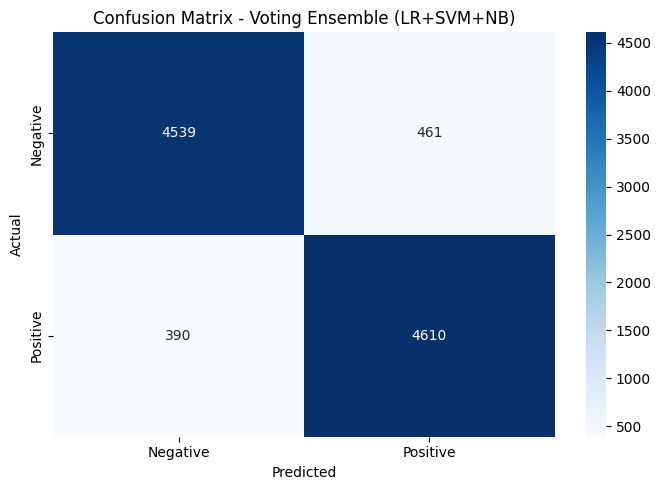

In [21]:
y_pred = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix - {best_model_name}")
plt.tight_layout()
plt.show()

In [22]:
print(f"Classification Report - {best_model_name}")
print("="*50)
print(classification_report(y_test, y_pred))

Classification Report - Voting Ensemble (LR+SVM+NB)
              precision    recall  f1-score   support

    negative       0.92      0.91      0.91      5000
    positive       0.91      0.92      0.92      5000

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000



In [23]:
import pickle

pickle.dump(best_model, open('model.pkl', 'wb'))
pickle.dump(vectorizer, open('vectorizer.pkl', 'wb'))

print("model.pkl      saved successfully!")
print("vectorizer.pkl saved successfully!")

model.pkl      saved successfully!
vectorizer.pkl saved successfully!


In [25]:
from google.colab import files
files.download('model.pkl')
files.download('vectorizer.pkl')
print("Files downloaded!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Files downloaded!


In [26]:
app_code = '''import streamlit as st
import pickle
import re
import numpy as np
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords

# Load NLP tools
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

# Load trained model & vectorizer
model = pickle.load(open('model.pkl', 'rb'))
vectorizer = pickle.load(open('vectorizer.pkl', 'rb'))

# Page config
st.set_page_config(page_title="Movie Sentiment Analyzer", layout="centered")

# CSS Styling
st.markdown("""
<style>
.title    { text-align:center; font-size:34px; font-weight:600; }
.subtitle { text-align:center; color:gray; margin-bottom:25px; }
.result-pos { background:#16a34a; color:white; padding:14px;
              border-radius:8px; text-align:center; font-size:18px; margin-top:15px; }
.result-neg { background:#dc2626; color:white; padding:14px;
              border-radius:8px; text-align:center; font-size:18px; margin-top:15px; }
.explain-box { background:#f1f5f9; padding:15px; border-radius:10px; margin-top:15px; }
</style>
""", unsafe_allow_html=True)

# Title
st.markdown('<div class="title">Movie Sentiment Analysis</div>', unsafe_allow_html=True)
st.markdown('<div class="subtitle">NLP-based sentiment classification system</div>', unsafe_allow_html=True)

# Text Input
review = st.text_area("Enter your movie review", height=150)

# Preprocessing function
def preprocess(text):
    text = text.lower()
    text = re.sub(r"[^a-zA-Z ]", "", text)
    tokens = text.split()
    new_tokens = []
    i = 0
    while i < len(tokens):
        if tokens[i] == "not" and i+1 < len(tokens):
            new_tokens.append("not_" + tokens[i+1])
            i += 2
        else:
            new_tokens.append(tokens[i])
            i += 1
    tokens = new_tokens
    tokens = [w for w in tokens if w not in stop_words]
    tokens = [lemmatizer.lemmatize(w) for w in tokens]
    return " ".join(tokens)

# Explanation function
def explain_prediction(text):
    feature_names = np.array(vectorizer.get_feature_names_out())
    vector = vectorizer.transform([text])
    if hasattr(model, "coef_"):
        coefs = model.coef_[0]
        indices = vector.nonzero()[1]
        important = sorted(
            [(feature_names[i], coefs[i]) for i in indices],
            key=lambda x: abs(x[1]), reverse=True
        )
        important = [w for w in important if abs(w[1]) > 0.5][:5]
        return important
    return []

# Predict button
if st.button("Analyze"):
    if review.strip() == "":
        st.warning("Please enter a review first.")
    else:
        cleaned = preprocess(review)
        vector = vectorizer.transform([cleaned])
        prediction = model.predict(vector)[0]

        if prediction == "positive":
            st.markdown('<div class="result-pos">Positive Sentiment</div>', unsafe_allow_html=True)
        else:
            st.markdown('<div class="result-neg">Negative Sentiment</div>', unsafe_allow_html=True)

        st.markdown("### Model Explanation")
        st.caption("Key words influencing the prediction")
        words = explain_prediction(cleaned)
        if words:
            st.markdown('<div class="explain-box">', unsafe_allow_html=True)
            for word, weight in words:
                impact = "Positive" if weight > 0 else "Negative"
                st.write(f"• **{word}** -> {impact} influence")
            st.markdown("</div>", unsafe_allow_html=True)
        else:
            st.write("Explanation not available for this model.")

st.markdown("---")
st.markdown("Sentiment Analysis System | NLP Lab 08")
'''

with open('app.py', 'w') as f:
    f.write(app_code)

print("app.py created successfully!")
print("\nSteps to run the GUI:")
print("1. Download app.py using: files.download('app.py')")
print("2. Download model.pkl and vectorizer.pkl (Cell 13)")
print("3. Place all 3 files in the same folder")
print("4. Run: pip install streamlit nltk scikit-learn")
print("5. Run: streamlit run app.py")

app.py created successfully!

Steps to run the GUI:
1. Download app.py using: files.download('app.py')
2. Download model.pkl and vectorizer.pkl (Cell 13)
3. Place all 3 files in the same folder
4. Run: pip install streamlit nltk scikit-learn
5. Run: streamlit run app.py


In [27]:
from google.colab import files
files.download('app.py')
print("app.py downloaded!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

app.py downloaded!


In [31]:
!pip install streamlit nltk scikit-learn


In [33]:
!streamlit run app.py




  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://35.198.232.162:8501

  Stopping...


In [38]:

!pip install streamlit pyngrok -q

import nltk
nltk.download('stopwords')
nltk.download('wordnet')

import subprocess
import threading
process = subprocess.Popen(['streamlit', 'run', 'app.py',
                            '--server.port', '8501',
                            '--server.headless', 'true'])

from pyngrok import ngrok

ngrok.kill()

ngrok.set_auth_token("3BDLvdeFFF7Evupf7aSEEH3t2LN_7PjTXL9mv6P4cv4dtY2p4")
public_url = ngrok.connect(8501)
print("=" * 50)
print("✅ YOUR STREAMLIT APP IS LIVE!")
print(f"🔗 Open this link: {public_url}")
print("=" * 50)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


✅ YOUR STREAMLIT APP IS LIVE!
🔗 Open this link: NgrokTunnel: "https://covetously-nonseraphic-terrie.ngrok-free.dev" -> "http://localhost:8501"
